In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("..\\processed\\deseq2_results.csv", index_col=0)
df.head(5)

,ensembl_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_symbol
1,ENSMUSG00000000001,6136.874607,-0.341334,0.223928,-1.524300,0.127434,0.582258,Gnai3
2,ENSMUSG00000000003,0.000000,NaN,NaN,NaN,NaN,NaN,Pbsn
3,ENSMUSG00000000028,2513.853135,-0.149251,0.191508,-0.779348,0.435775,0.851034,Cdc45
4,ENSMUSG00000000031,10.792420,-5.032144,1.647705,-3.054032,0.002258,0.070244,H19
5,ENSMUSG00000000037,81.673642,-0.845251,0.405255,-2.085728,0.037003,0.342430,Scml2


In [2]:
df = df.dropna(subset=['log2FoldChange'])
df = df.dropna(subset=['padj'])
df.head(5)

,ensembl_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_symbol
1,ENSMUSG00000000001,6136.874607,-0.341334,0.223928,-1.524300,0.127434,0.582258,Gnai3
3,ENSMUSG00000000028,2513.853135,-0.149251,0.191508,-0.779348,0.435775,0.851034,Cdc45
4,ENSMUSG00000000031,10.792420,-5.032144,1.647705,-3.054032,0.002258,0.070244,H19
5,ENSMUSG00000000037,81.673642,-0.845251,0.405255,-2.085728,0.037003,0.342430,Scml2
7,ENSMUSG00000000056,1345.619943,-0.082373,0.236994,-0.347572,0.728161,0.947779,Narf


In [24]:
df['-log10_padj'] = -np.log10(df['padj'])
df['mark'] = 'unsig'

df.loc[(df['padj'] < 0.05) & (df['log2FoldChange'] > 1), 'mark'] = 'up'

df.loc[(df['padj'] < 0.05) & (df['log2FoldChange'] < -1), 'mark'] = 'down'

In [25]:
display(df)

,ensembl_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_symbol,-log10_padj,mark,care
1,ENSMUSG00000000001,6136.874607,-0.341334,0.223928,-1.524300,0.127434,0.582258,Gnai3,0.234884,unsig,False
3,ENSMUSG00000000028,2513.853135,-0.149251,0.191508,-0.779348,0.435775,0.851034,Cdc45,0.070053,unsig,False
4,ENSMUSG00000000031,10.792420,-5.032144,1.647705,-3.054032,0.002258,0.070244,H19,1.153390,unsig,False
5,ENSMUSG00000000037,81.673642,-0.845251,0.405255,-2.085728,0.037003,0.342430,Scml2,0.465428,unsig,False
7,ENSMUSG00000000056,1345.619943,-0.082373,0.236994,-0.347572,0.728161,0.947779,Narf,0.023293,unsig,False
...,...,...,...,...,...,...,...,...,...,...,...
55366,ENSMUSG00000118521,9.747778,0.375175,1.158256,0.323914,0.746003,0.952291,Gm52948,0.021230,unsig,False
55382,ENSMUSG00000118537,162.965920,-0.178001,0.355723,-0.500391,0.616799,0.921197,Shld3,0.035647,unsig,False
55395,ENSMUSG00000118550,67.903914,0.897762,0.454865,1.973688,0.048417,0.384059,Gm52965,0.415602,unsig,False
55404,ENSMUSG00000118559,364.586990,-0.749640,0.283288,-2.646215,0.008140,0.153976,A930007A09Rik,0.812547,unsig,False


In [26]:
update_care_info = False

if (update_care_info):
    df['care'] = 0
    care_info_list = ['log2FoldChange', 'padj', 'gene_symbol', 'care']

    df_care_up = df[(df['log2FoldChange'] > 2) & (df['padj'] < 0.05)].copy()
    df_care_up.sort_values(by='padj', ascending=True, inplace=True)
    df_care_up[care_info_list].to_csv('..\\caring\\care_up.csv')

    df_care_down = df[(df['log2FoldChange'] < -2) & (df['padj'] < 0.05)].copy()
    df_care_down.sort_values(by='padj', ascending=True, inplace=True)
    df_care_down[care_info_list].to_csv('..\\caring\\care_down.csv')

In [27]:
df_care_up = pd.read_csv('..\\caring\\care_up.csv', index_col=0)

df_care_down = pd.read_csv('..\\caring\\care_down.csv', index_col=0)

df['care'] = False

for index, row in df_care_up.iterrows():
    if (row['care']==1): df.at[index, 'care'] = True

for index, row in df_care_down.iterrows():
    if (row['care']==1): df.at[index, 'care'] = True

for index, row in df_care_up.iterrows():
    if df.at[index, 'care'] == True : print(f"up: index of {row['gene_symbol']} = {index}")

for index, row in df_care_down.iterrows():
    if df.at[index, 'care'] == True : print(f"down: index of {row['gene_symbol']} = {index}")

up: index of Fmn1 = 13019
up: index of Mroh4 = 3789
down: index of Icosl = 125
down: index of Aire = 124
down: index of Dnmt3l = 123


In [28]:
offset_data = {
    # 'Gpc6':(2.3, 1.5),
    'Fmn1':(1.9, 2.5),
    'Mroh4':(1.6, 2.2),
    # 'Meltf':(1.3, 1.5),
    'Icosl':(-0.9, 1.0),
    # 'Khdc3':(-1.5, 2.4),
    'Aire':(-1.7, 3.2),
    'Dnmt3l':(-1.8, 1.3)
}

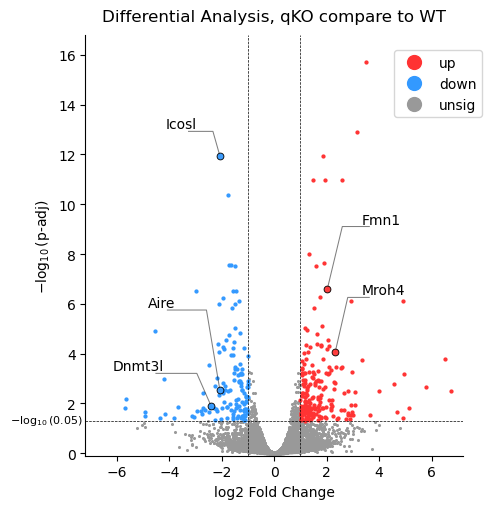

In [60]:
from matplotlib.lines import Line2D

# Initialize plot
plt.figure(figsize=(5, 5.2))

color_ = '#999999'; color1 = '#ff3333'; color2 = '#3399ff'
# color_ = '#999999'; color2 = '#b708fc'; color1 = '#fa8805'
#FFD43B
def plot_basic(data: pd.DataFrame, color: str, alpha: float, size: float = 1.5, zorder = 1):
    
    alpha = 1
    plt.scatter(data['log2FoldChange'], data['-log10_padj'],
                s=size, c=color, zorder=zorder, alpha=alpha)
    
def plot_care(data: pd.DataFrame, color: str, alpha: float, size: float = 50, trim=0.65,
              ha='right', va='bottom', offset=False,
              t_path=False, t_path_xelong=-0.3):
    
    for i in range(len(data)):
        x = data['log2FoldChange'].iat[i]; y = data['-log10_padj'].iat[i]; s = data['gene_symbol'].iat[i]
        ofx = offset[s][0] if isinstance(offset, dict) else 0
        ofy = offset[s][1] if isinstance(offset, dict) else 0
        first_char = s[0]
        rest = s[1:]
        # Use mathtext to bold the first character
        emphasized = first_char +rest
        const_right_feedback = 0
        if (ha=='left'): const_right_feedback = 0.6
        plt.text(x+ofx-const_right_feedback,
                y+ofy, s=emphasized, fontsize=10, ha=ha, va=va)
        if (t_path):
            tx = x+ofx; ty = y+ofy
            zigzag_path = [(x, y), (x + ofx * 0.3, y + ofy), (tx+t_path_xelong, ty)]
            xs, ys = zip(*zigzag_path)
            plt.plot(xs, ys, color='black', linewidth=0.75, zorder=5, alpha=0.5)
       
    plt.scatter(data['log2FoldChange'], data['-log10_padj'], zorder = 10,
                s=size, c=color, edgecolors='black', linewidths=trim, alpha=alpha)
    
##############################################################################

plot_basic(df[(df['mark'] == 'unsig') & (df['care'] == False)], color=color_, alpha=0.85)
plot_basic(df[(df['mark'] == 'up') & (df['care'] == False)], color=color1, alpha=0.52, size=4.2)
plot_basic(df[(df['mark'] == 'down') & (df['care'] == False)], color=color2, alpha=0.52, size=4.2)

plot_care(df[(df['mark'] == 'up') & (df['care'] == True)],
          color=color1, alpha=0.95, size=24, ha='left', va='bottom',
          offset=offset_data, t_path=True)
plot_care(df[(df['mark'] == 'down') & (df['care'] == True)],
          color=color2, alpha=0.95, size=24, ha='right', va='bottom',
          offset=offset_data, t_path=True)

# Axis labels
plt.xlabel("log2 Fold Change")
plt.ylabel(r"$-\log_{10}(\text{p-adj})$")
plt.title("Differential Analysis, qKO compare to WT", fontsize=12, pad=10)

# horizontal/vertical reference lines
plt.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.5)
plt.axvline(-1, color='black', linestyle='--', linewidth=0.5)
plt.axvline(1, color='black', linestyle='--', linewidth=0.5)

plt.xlim(-7.2,7.2)
plt.ylim(-0.1,16.8)

def l2Dobj(x, y, color, label, alpha=1):
    return Line2D([x], [y], marker='o', color='w', label=label,
                  markerfacecolor=color, markersize=12, alpha=alpha)

legend_elements = (l2Dobj(0, 0, color1, 'up'), l2Dobj(0, 0, color2, 'down'), l2Dobj(0, 0, color_, 'unsig'))

plt.legend(handles=legend_elements, bbox_to_anchor=(0.8, 0.98), loc='upper left', fontsize=10, frameon=True)

for spine in plt.gca().spines:
    # print(spine)
    if (spine in ['top', 'right']):
        plt.gca().spines[spine].set_visible(False)

# text "-log10(0.05) on left side of horizontal dashed line"
plt.text(-7.3, -np.log10(0.05)-0.25, r"$-\log_{10}(\text{0.05})$", va='bottom', ha='right', fontsize=8)

plt.tight_layout()
plt.savefig("..\\figures\\volcano_plot.pdf", transparent=False)
plt.savefig("..\\figures\\volcano_plot.png", dpi=300, transparent=False)
plt.savefig("..\\figures\\volcano_plot.svg", transparent=False)
plt.show()